# Elastic Net Regression

## Objective

In this notebook, we will practice:

- Linear Regression baseline
- Elastic Net Regression
- L1 Regularization
- L2 Regularization
- Alpha parameter
- L1 Ratio
- Coefficient shrinkage
- Feature selection
- Model evaluation
- Comparing different alpha values
- Comparing different l1_ratio values

## Dataset

Heart Failure Clinical Records Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import ElasticNet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv(
    "../../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [4]:
print("Shape:", df.shape)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

df.describe()

Shape: (299, 10)
Missing Values: 0


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000


# Preparing Data

We will use the following numerical features:

- age
- creatinine_phosphokinase
- ejection_fraction
- platelets
- serum_sodium

Target:

- serum_creatinine

In [5]:
features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_sodium"
]

X = df[features]

y = df["serum_creatinine"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (299, 5)
y Shape: (299,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 239
Testing Rows: 60


# Elastic Net Regression

Elastic Net combines:

- L1 Regularization from Lasso
- L2 Regularization from Ridge

Important parameters:

- alpha → overall regularization strength
- l1_ratio → balance between L1 and L2

In [7]:
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        ElasticNet(
            alpha=0.1,
            l1_ratio=0.5,
            max_iter=10000
        )
    )
])

elastic_pipeline.fit(
    X_train,
    y_train
)

elastic_pred = elastic_pipeline.predict(
    X_test
)

In [8]:
elastic_mae = mean_absolute_error(
    y_test,
    elastic_pred
)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        elastic_pred
    )
)

elastic_r2 = r2_score(
    y_test,
    elastic_pred
)

print("Elastic Net Regression")
print("MAE :", round(elastic_mae, 3))
print("RMSE:", round(elastic_rmse, 3))
print("R²  :", round(elastic_r2, 3))

Elastic Net Regression
MAE : 0.563
RMSE: 1.162
R²  : 0.026


In [9]:
elastic_model = elastic_pipeline.named_steps["model"]

elastic_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": elastic_model.coef_
})

elastic_coefficients.round(4)

,Feature,Coefficient
0,age,0.0553
1,creatinine_phosphokinase,0.0000
2,ejection_fraction,0.0000
3,platelets,-0.0117
4,serum_sodium,-0.1578


# Effect of Alpha

We will test different alpha values.

Small alpha:
- Weak regularization

Large alpha:
- Strong regularization
- More coefficient shrinkage
- May produce more zero coefficients

In [10]:
alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10
]

alpha_results = []

for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "elastic",
            ElasticNet(
                alpha=alpha,
                l1_ratio=0.5,
                max_iter=10000
            )
        )
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    coefficients = (
        model.named_steps["elastic"].coef_
    )

    zero_count = np.sum(
        coefficients == 0
    )

    alpha_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Zero Coefficients": zero_count
    })

alpha_results = pd.DataFrame(alpha_results)

alpha_results.round(4)

,Alpha,MAE,RMSE,R²,Zero Coefficients
0,0.001,0.5816,1.1720,0.0102,0
1,0.010,0.5787,1.1701,0.0133,0
2,0.100,0.5631,1.1623,0.0264,2
3,1.000,0.5924,1.1784,-0.0008,5
4,10.000,0.5924,1.1784,-0.0008,5


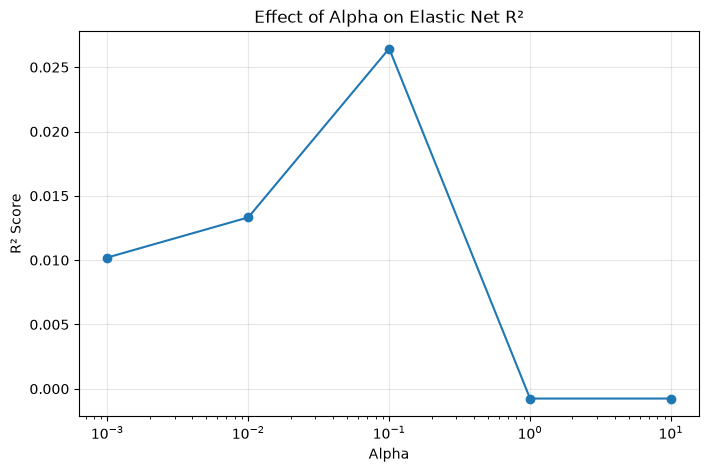

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["R²"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R² Score")

plt.title(
    "Effect of Alpha on Elastic Net R²"
)

plt.grid(alpha=0.3)

plt.show()

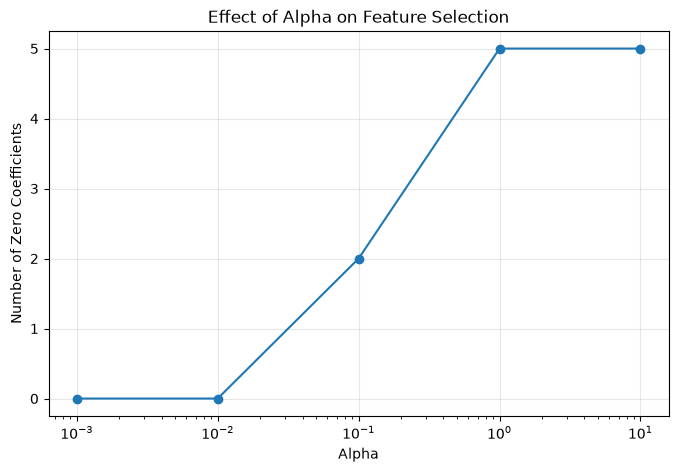

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["Zero Coefficients"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Number of Zero Coefficients")

plt.title(
    "Effect of Alpha on Feature Selection"
)

plt.grid(alpha=0.3)

plt.show()

# Effect of L1 Ratio

The `l1_ratio` controls the balance between L1 and L2 regularization.

```text
l1_ratio = 0
→ Ridge-like

l1_ratio = 1
→ Lasso-like

l1_ratio = 0.5
→ Balanced L1 + L2

In [13]:
l1_ratios = [
    0,
    0.25,
    0.5,
    0.75,
    1
]

ratio_results = []

for ratio in l1_ratios:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "elastic",
            ElasticNet(
                alpha=0.1,
                l1_ratio=ratio,
                max_iter=10000
            )
        )
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    coefficients = (
        model.named_steps["elastic"].coef_
    )

    zero_count = np.sum(
        coefficients == 0
    )

    ratio_results.append({
        "L1 Ratio": ratio,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Zero Coefficients": zero_count
    })

ratio_results = pd.DataFrame(ratio_results)

ratio_results.round(4)

,L1 Ratio,MAE,RMSE,R²,Zero Coefficients
0,0.00,0.5765,1.1695,0.0144,0
1,0.25,0.5654,1.1632,0.0249,0
2,0.50,0.5631,1.1623,0.0264,2
3,0.75,0.5677,1.1662,0.0199,3
4,1.00,0.5733,1.1720,0.0102,3


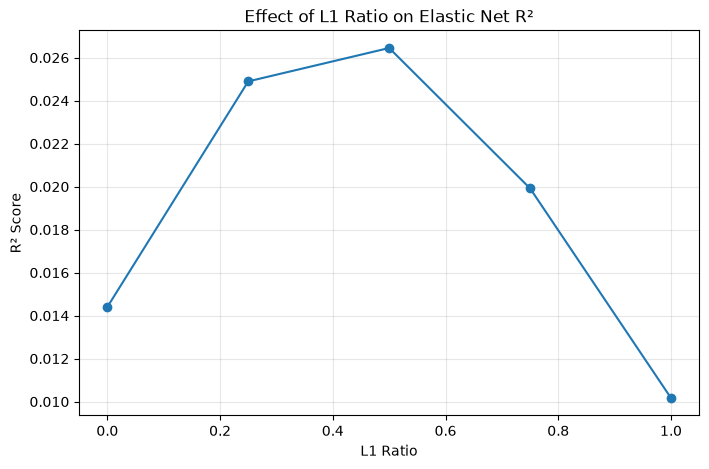

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    ratio_results["L1 Ratio"],
    ratio_results["R²"],
    marker="o"
)

plt.xlabel("L1 Ratio")
plt.ylabel("R² Score")

plt.title(
    "Effect of L1 Ratio on Elastic Net R²"
)

plt.grid(alpha=0.3)

plt.show()

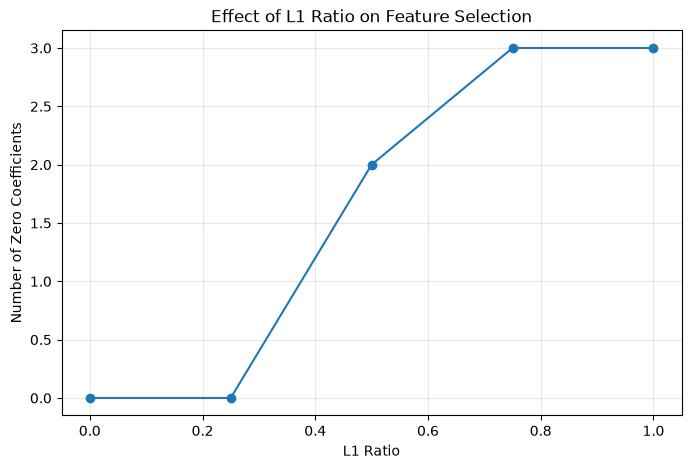

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    ratio_results["L1 Ratio"],
    ratio_results["Zero Coefficients"],
    marker="o"
)

plt.xlabel("L1 Ratio")
plt.ylabel("Number of Zero Coefficients")

plt.title(
    "Effect of L1 Ratio on Feature Selection"
)

plt.grid(alpha=0.3)

plt.show()

# Regularization Comparison

We will compare:

- Ridge
- Lasso
- Elastic Net

The goal is to understand how different regularization methods affect model performance and coefficients.

In [16]:
from sklearn.linear_model import Ridge, Lasso

models = {
    "Ridge": Ridge(alpha=0.1),
    "Lasso": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=10000
    )
}

comparison_results = []

for name, estimator in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    comparison_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

comparison = pd.DataFrame(
    comparison_results
)

comparison.round(4)

,Model,MAE,RMSE,R²
0,Ridge,0.5819,1.1722,0.0099
1,Lasso,0.5733,1.1720,0.0102
2,Elastic Net,0.5631,1.1623,0.0264


# Summary

## Elastic Net

Elastic Net combines:

- L1 Regularization
- L2 Regularization

## Alpha

Controls overall regularization strength.

```text
alpha ↑
→ Stronger regularization